---
# Import Library

---

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

---
# Data Loading

---

First, we will load the `modelling_df` data, that is constructed at the **order-item level** which:
- 1 row represents 1 product item within an order
- A single `order_id` may appear multiple times if the order contains multiple products

This dataset will assign to the variable `df`:

In [2]:
# Since the data is located on directory '../data/cleaned' from DE part:
df = pd.read_csv('../data/cleaned/modelling_df_v0_1.csv', index_col=0) # use index column
backup_df = df.copy() # for backup of changes in original df

# Check the summary with info method()
df.info()

pd.set_option('display.max_columns', None) # to see all columns
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 117784 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117784 non-null  object 
 1   customer_id                    117784 non-null  object 
 2   order_status                   117784 non-null  object 
 3   order_purchase_timestamp       117784 non-null  object 
 4   order_approved_at              117608 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117784 non-null  object 
 8   order_item_id                  117597 non-null  float64
 9   product_id                     117597 non-null  object 
 10  shipping_limit_date            117597 non-null  object 
 11  price                          117597 non-null  float64
 12  freight_value                  1175

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,060cb19345d90064d1015407193c233d,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,a1804276d9941ac0733cfd409f5206eb,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,4520766ec412348b8d4caa5e8a18c464,2017-05-22 13:22:11,59.99,15.17

Second, we will also load the `order_agg_modeling` data, that constructed of aggregated of raw data, for each orders. This is to further analyze whether we will use the **order-item level** or **order level** only for the analysis of cancellation rate further. This dataset will be assign to the variable `df_agg`:

In [3]:
# Aggregated data also located in same directory '../data/cleaned' from DE part:
df_agg = pd.read_csv('../data/cleaned/order_agg_modeling_v0_1.csv', index_col=0) # use index column
backup_df_agg = df_agg.copy() # for backup of changes in original df_agg

# Check the summary with info method()
df_agg.info()

df_agg.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 98832 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98832 non-null  object 
 1   customer_id                    98832 non-null  object 
 2   order_status                   98832 non-null  object 
 3   order_purchase_timestamp       98832 non-null  object 
 4   order_approved_at              98672 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  98832 non-null  object 
 8   total_items                    98660 non-null  float64
 9   total_order_value              98660 non-null  float64
 10  total_freight                  98660 non-null  float64
 11  avg_item_price                 98660 non-null  float64
 12  payment_type                   98831 non-null  obje

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,29.99,voucher,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,118.70,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,147.90,27.36,147.90,credit_card,175.26,6.0,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,49.90,16.05,49.90,credit_card,65.95,1.0,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,59.99,15.17,59.99,credit_card,75.16,3.0,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,19.90,16.05,19.90,boleto,35.95,1.0,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1.0,149.99,19.77,149.99,credit_card,169.76,1.0,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,0


Note that above data `df` and `df_agg` have some missing values. These will be handle on the next process later.

If we look out for how many orders that comes from each customer:

In [4]:
df.customer_id.value_counts()

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
63b964e79dee32a3587651701a2b8dbf    24
                                    ..
741a12b94b48a426f2cbd87b83a62c29     1
7fb28b72559f15550a82e040b117dcc6     1
d75f7a65c23672520fa4dc4125443ff9     1
6a2896a95ecb9df4c195ac3ba4139cf7     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 98832, dtype: int64

Note that there are some customers with multiple orders on the dataset. Perhaps there may be multiple cancelled order for each customer that later we will observed.

---
# Data Cleaning
---

## Missing Values on `df`:

In [5]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     1424
order_delivered_customer_date    2747
order_estimated_delivery_date       0
order_item_id                     187
product_id                        187
shipping_limit_date               187
price                             187
freight_value                     187
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_name_lenght              1885
product_description_lenght       1885
product_photos_qty               1885
product_weight_g                  207
product_length_cm                 207
product_heig

We can categorize above missing values as follows:
- The missing values on date columns (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`)
- Missing on order items data (`order_item_id`, `product_id`, `shipping_limit_date`, `price`, `freight_value`)
- Payment data missing (`payment_sequential`, `payment_type`, `payment_installments`, `payment_value`)
- Missing of product details (`product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`)

Checking for each category:

### Missing on Date Columns:

In [6]:
df_date = df[[
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]]
df_date[df_date.isna().any(axis=1)]

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
8,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
51,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
125,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
155,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
192,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...
118081,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
118124,2018-02-17 14:31:22,2018-02-20 07:11:31,2018-02-20 19:18:58,NaN,2018-03-14 00:00:00
118237,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
118286,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00


Note that, some of the missing values above are comes from `order_delivered_customer_date`. In this project, we concerned for the cancellation rate and later want to predict whether the order will be cancelled or not. In the future, we will notify the warning of such order will be cancelled **prior the order approved by the system**, let alone the order delivered to the customer. So, all of the date columns above **except** `order_purchase_timestamp` will not available in real scenario, or if available will not be used. Therefore, following primary objective of this project, we choose to drop all date columns **except** `order_purchase_timestamp`:

In [7]:
df = df.drop(columns=[
    'order_approved_at', 'order_delivered_carrier_date', 
    'order_delivered_customer_date', 'order_estimated_delivery_date'
], axis=1)

### Missing on Order Items Columns:

First, we will check all data where `order_item_id` missing:

In [8]:
missing_order_items = df[df['order_item_id'].isna()]
missing_order_items

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
1352,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,NaN,NaN,1.0,not_defined,1.0,0.00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2128,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,191.46,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2218,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,NaN,NaN,1.0,boleto,1.0,139.96,c219f4ac1bc7f1aea33e6ab8885831e8,68742,castanhal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2415,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,66.44,a8dd81392e5eee5d979c629a76abec2a,13059,campinas,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2570,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,2.0,72.90,29dc4aeff866d6a940c471a3ea4faef0,5752,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116292,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,1.0,157.13,40d1c2a6b8ac6ccc102d473ff51cc46d,29156,cariacica,ES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
117179,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,1.0,280.20,aa75afb965e89078d8681fe33aaaeded,12940,atibaia,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
117771,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,54.42,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,63.89,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


If we check other order items columns as well:

In [9]:
cols_to_check = [
    'product_id','shipping_limit_date',
    'price','freight_value'
]

missing_order_items[cols_to_check].isna().all(axis=1).value_counts()

True    187
Name: count, dtype: int64

Hence, all columns of order items that is `order_item_id`, `product_id`, `shipping_limit_date`, `price`, and `freight_value` all simultaneously missing for the same `order_id`.

In [10]:
order_id_missing_order_items = missing_order_items['order_id'].unique().tolist()

check_original = df[
    (df['order_id'].isin(order_id_missing_order_items)) &
    (df['order_item_id'].notna())
]

check_original.shape

(0, 25)

Based on above output, we can see that all 172 `order_id` does not have all order items columns at all. Before deciding any treatment, we will check the distribution of `is_canceled` for these orders to understand whether this is a data issue or a business process event (that is canceled orders).

In [11]:
missing_order_items['is_canceled'].value_counts()

is_canceled
1    179
0      8
Name: count, dtype: int64

From the distribution above, we observe that most (or all) of these orders
are labeled as `is_canceled`. This indicates that the absence of order item column information is not due to random missing values, but likely due to the order was canceled before item fulfillment was recorded. Therefore, these rows represent structurally missing rather than incomplete data.

For further exploratory analysis (correlation analysis and aggregation), we will temporarily impute these missing order item fields.

- Imputation performed only for EDA purposes, not imply that htese orders contain actual items
- FIlling identifier columns with label `"no_item"`, numerical columns with 0 (structural absence), and datetime with `NaT`

In [12]:
missing_index = missing_order_items.index

# Numeric columns → structural zero
df.loc[missing_index, 'order_item_id'] = 0
df.loc[missing_index, 'price'] = 0
df.loc[missing_index, 'freight_value'] = 0

# Categorical
df.loc[missing_index, 'product_id'] = 'no_item'

# Datetime
df.loc[missing_index, 'shipping_limit_date'] = pd.NaT

In [13]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_item_id                    0
product_id                       0
shipping_limit_date            187
price                            0
freight_value                    0
payment_sequential               3
payment_type                     3
payment_installments             3
payment_value                    3
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_name_lenght           1885
product_description_lenght    1885
product_photos_qty            1885
product_weight_g               207
product_length_cm              207
product_height_cm              207
product_width_cm               207
is_canceled                      0
dtype: int64

Note that column `shipping_limit_date` still missing. However, following same behavior with previous date columns, since we concern before the order approved, this column `shipping_limit_date` should not be available. We will drop this column as well.

In [14]:
df = df.drop(columns=['shipping_limit_date'], axis = 1)

### Missing on Payment Data Columns:

We will check based on column `payment_sequential` first:

In [15]:
missing_payment = df[df['payment_sequential'].isna()]
missing_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
36657,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,1.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0
36658,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0
36659,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,3.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0


In [16]:
# check other column payment data
cols_to_check = [
    'payment_type', 'payment_installments', 'payment_value'
]

missing_payment[cols_to_check].isna().all(axis=1).value_counts()

True    3
Name: count, dtype: int64

Note that, all columns of payment data that is `payment_sequential`, `payment_type`, `payment_installments`, and `payment_value` all simultaneously missing for the same `order_id`. All 3 rows occurred for the `order_id` **bfbd0f9bdef84302105ad712db648a6c**. Also, by checking other columns values, no other columns affected this missingness, hence it is **MCAR** type of missing.

Since payment information represents transactional entity, rows without any payment data not provide meaningful analytical value. We conclude to remove these 3 rows to maintain data integrity for further exploratory analysis, due no partial information can be reasonably imputed.

In [17]:
df = df.dropna(subset=['payment_sequential']) # since other columns follows

### Missing on Product Detail Columns:

We will check based on column `product_name_lenght` first:

In [18]:
missing_product = df[df['product_name_lenght'].isna()]
missing_product

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
129,bfe42c22ecbf90bc9f35cf591270b6a7,803ac05904124294f8767894d6da532b,delivered,2018-01-27 22:04:34,1.0,71225f49be70df4297892f6a5fa62171,27.30,15.10,1.0,credit_card,1.0,42.40,34c58672601f2c6d29db7efd1f6bf958,38650,bonfinopolis de minas,MG,NaN,NaN,NaN,200.0,16.0,2.0,11.0,0
221,58ac1947c1a9067b9f416cba6d844a3f,ee8e1d37f563ecc11cc4dcb4dfd794c2,delivered,2017-09-13 09:18:50,1.0,9820e04e332fc450d6fd975befc1bc28,110.00,14.16,1.0,credit_card,5.0,124.16,5cbf29b2dcf212a6a5d864b887238c72,4842,sao paulo,SP,NaN,NaN,NaN,10800.0,40.0,40.0,30.0,0
274,e22b71f6e4a481445ec4527cb4c405f7,1faf89c8f142db3fca6cf314c51a37b6,delivered,2017-04-22 13:48:18,1.0,3bc5164bc7f4be77002d6651da65c98c,22.50,11.74,1.0,credit_card,3.0,34.24,1268b060098ed3f22c2e7c34cc72a1a8,38240,itapagipe,MG,NaN,NaN,NaN,550.0,16.0,11.0,19.0,0
316,a094215e786240fcfefb83d18036a1cd,86acfb656743da0c113d176832c9d535,delivered,2018-02-08 18:56:45,1.0,5a848e4ab52fd5445cdc07aab1c40e48,122.99,9.06,1.0,credit_card,1.0,132.05,f5cb81f98962f7504bef1e75579b6dff,13474,americana,SP,NaN,NaN,NaN,400.0,20.0,12.0,15.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118171,f0dd9af88d8ef5a8e4670fbbedaf19c4,30ddb50bd22ee927ebe308ea3da60735,delivered,2017-09-02 20:38:29,1.0,0c877471e35049402bca235e06cb8063,84.90,15.35,1.0,boleto,1.0,100.25,1d627d8a6e1e33ea8eeeb7a17d998660,11045,santos,SP,NaN,NaN,NaN,10750.0,34.0,20.0,30.0,0
118177,272874573723eec18f23c0471927d778,48e080c8001e92ebea2b64e474f91a60,delivered,2017-12-20 23:10:33,1.0,5a848e4ab52fd5445cdc07aab1c40e48,122.99,9.06,1.0,credit_card,5.0,132.05,da59579685bd771fdd4f90fb50d28cd3,7240,guarulhos,SP,NaN,NaN,NaN,400.0,20.0,12.0,15.0,0
118198,dff2b9b8d7cfc595836945e1443789c3,2436fb2666a65fbacae82532e797cabf,delivered,2018-07-16 12:59:02,1.0,bfa0e398bef2d28bb421d42997982cab,219.99,15.13,1.0,boleto,1.0,235.12,9b352d0736779ff0e21fcbd59a7141b3,22641,rio de janeiro,RJ,NaN,NaN,NaN,3100.0,28.0,20.0,40.0,0
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,0.0,no_item,0.00,0.00,1.0,voucher,1.0,63.89,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


If we check for other column product, only for column `product_description_lenght` and `product_photos_qty` first:

In [19]:
# check other column product detail
cols_to_check = [
    'product_description_lenght', 'product_photos_qty'
]

missing_product[cols_to_check].isna().all(axis=1).value_counts()

True    1885
Name: count, dtype: int64

By above output shows all columns `product_name_lenght`, `product_description_lenght`, and `product_photos_qty` are simulatenously missing for the same `order_id` on all 1885 records on `missing_product` dataframe. Later on EDA question 3, we will further analyze based on products and turns out we will not utilize order-item dataset (based on each order and each product for that order). 

We conclude, the orders without the products information are not concerned (in fact, we will not use all of these columns further). Therefore, all of these records (these 1885 rows) will be dropped and not be used further.

In [20]:
df = df.dropna(subset=['product_name_lenght']) # since other columns follows

# recheck missing
df.isna().sum()

order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_item_id                 0
product_id                    0
price                         0
freight_value                 0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
is_canceled                   0
dtype: int64

Same arguments earlier, we will also drop records where column `product_weight_g` missing (probably other column `product_length_cm`, `product_height_cm`, and `product_width_cm` comes from same order):

In [21]:
df = df.dropna(subset=['product_weight_g']) # since other columns suspected to follows

# recheck missing
df.isna().sum()

order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_item_id                 0
product_id                    0
price                         0
freight_value                 0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
is_canceled                   0
dtype: int64

By above outputs, now the missing values completely handled for the order-item dataset `df`.

## Missing Values on `df_agg`:

In [22]:
df_agg.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1174
order_delivered_customer_date    2356
order_estimated_delivery_date       0
total_items                       172
total_order_value                 172
total_freight                     172
avg_item_price                    172
payment_type                        1
total_payment_value                 1
max_installments                    1
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
is_canceled                         0
dtype: int64

Note that the patterns of above missing values on the aggregated dataset `df_agg` similar as previous `df`, we can categorize as follows:
- Date columns (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`)
- Order items data (`total_items`, `total_order_value`, `total_freigh`, `avg_item_price`)
- Payment data (`payment_type`, `total_payment_value`, `max_installments`)
> Note that there are no product details data on aggregated dataset, because this aggregated dataset `df_agg` is consructed for order based and not concerning of products from each orders

Therefore, we can use similar arguments with what already done earlier on `df`:

### Missing on Date Columns:

Similar with what explained on `df` part before, we will drop all date columns **except** `order_purchase_timestamp`:

In [23]:
df_agg = df_agg.drop(columns=[
    'order_approved_at', 'order_delivered_carrier_date', 
    'order_delivered_customer_date', 'order_estimated_delivery_date'
], axis=1)

### Missing on Order Items Columns:

Since the order items column from aggregated dataset:
- `total_items` : comes from aggregated column `order_item_id` of non-aggregated dataset
- `total_order_value` : aggregated column `price` of non-aggregated dataset
- `total_freight` : aggregated column `freight_value` of non-aggregated dataset
- `avg_item_price` : aggregated column `price` of non-aggregated dataset

Hence, we can use similar arguments with what explained and performed on `df` dataset earlier. That is, we will temporarily impute the data of these missing (aggregated) order item fields only for further exploratory analysis (correlation and aggregation). With similar impute procedure as earlier:

In [24]:
# Recheck whether those 4 columns missing on the same records or not

missing_order_items = df_agg[df_agg['total_items'].isna()] # check based on column `total_items`
print(f'Number of `total_items` missing: {missing_order_items.shape[0]}')

cols_to_check = [
    'total_order_value','total_freight', 'avg_item_price'
]

missing_order_items[cols_to_check].isna().all(axis=1).value_counts()

Number of `total_items` missing: 172


True    172
Name: count, dtype: int64

Since all of those 4 columns are numerical, we will impute `0` as structural absence (same as what performed on `df` earlier):

In [25]:
# Impute process

missing_index = missing_order_items.index

# Numeric columns → structural zero
df_agg.loc[missing_index, 'total_items'] = 0.0
df_agg.loc[missing_index, 'total_order_value'] = 0.0
df_agg.loc[missing_index, 'total_freight'] = 0.0
df_agg.loc[missing_index, 'avg_item_price'] = 0.0

### Missing on Payment Data Columns:

If we check on column `payment_type` first:

In [26]:
missing_payment = df_agg[df_agg['payment_type'].isna()]
missing_payment

,order_id,customer_id,order_status,order_purchase_timestamp,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,3.0,134.97,8.49,44.99,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0


Note that, this is the same `order_id` **bfbd0f9bdef84302105ad712db648a6c** that earlier found on original dataset `df`. Turns out this same order also reflects with missing values of column `payment_type`, `total_payment_value`, and `max_installments` on aggregated data `df_agg`. With the same arguments, we conclude to drop this record also on `df_agg`:

In [27]:
df_agg = df_agg.dropna(subset=['payment_type']) # since other columns follows

In [28]:
# recheck missing
df_agg.isna().sum()

order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
total_items                 0
total_order_value           0
total_freight               0
avg_item_price              0
payment_type                0
total_payment_value         0
max_installments            0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
is_canceled                 0
dtype: int64

By above outputs, now the missing values completely handled for the aggregated dataset `df_agg` that depicts order based records. We can move further to the next process **Exploratory Data Analysis (EDA)** as main process on this notebook.

---
# Exploratory Data Analysis
---

All of the questions:
#TODO ini nanti crosscheck di discord lagi, siapa tau ada yang diedit, terutama nomor 3 itu baru dari bahasan ama bang kevin -- harapannya hasil dari nomor 3 ga bagus, maka nomor 4 dst cukup `df` aja, gaperlu 

1. What is the overall cancellation rate in the historical dataset?
2. What is the distribution of customer level cancellation rate? #TODO sepertinya malah jadi banyak cancellation paling tinggi dari setiap customer
3. How is the cancellation rate for each product? #TODO ini yang baru -- jadi per `product_id` bang
4. Which customer segments are most likely to cancel their orders based on transaction history
5. When do order cancellations most frequently occur?
6. Where do order cancellation most frequently occur, based on customer location?
7. Which features show the strongest relationship with order cancellations?
8. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?

---
## 1. Overall cancellation rate
---


In [29]:
# overall cancel rate for DF_Modeling
cancel_rate_df= (
    df['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_df

is_canceled
Not Canceled    0.995246
Canceled        0.004754
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

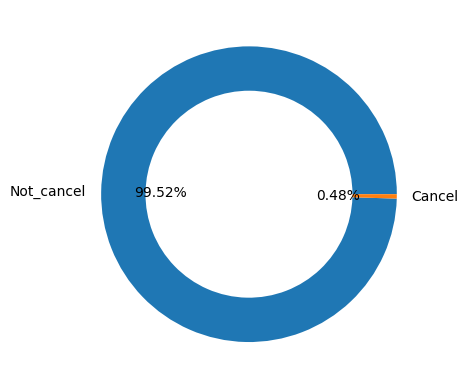

In [30]:
# Pie chart for DF_Modeling
plt.pie(
    cancel_rate_df.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.2f%%", # show 2 numbers after decimal
    explode=[0,0],
    wedgeprops={'width':0.3}
)
plt.show


This distribution from dataset `modelling_df` shows that most orders are not canceled, with a very low cancellation rate of around 0.48% of total transactions. This indicates that cancellations are not a systemic issue, but rather a relatively rare occurrence likely triggered by certain conditions or factors, such as payment methods, specific customer behavior, or particular transaction situations. 

Since `modelling_df` is structured at the **order-item level** (where one order can appear in multiple rows if it contains multiple products), this result reflects the cancellation distribution at the product-line level. This indicates that our data at this granularity is already **severely imbalanced**. If we check the aggregated dataset (`order_agg_modeling`), where each row represents one unique order:

In [31]:
# overall cancel rate for DF_Agg
cancel_rate_agg= (
    df_agg['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_agg

is_canceled
Not Canceled    0.993676
Canceled        0.006324
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

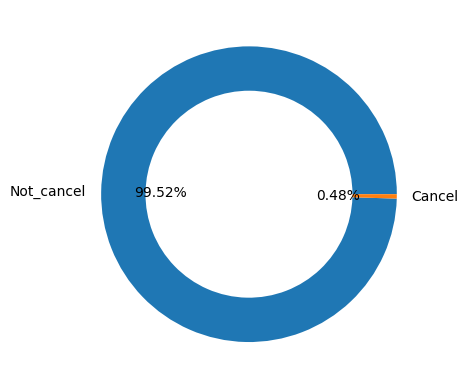

In [32]:
# Pie chart for DF_Agg
plt.pie(
    cancel_rate_df.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.2f%%", # show 2 numbers after decimal
    explode=[0,0],
    wedgeprops={'width':0.3}
)
plt.show


Similar to the distribution observed in `modelling_df`, the dataset `order_agg_modeling` also shows that most orders are not canceled, with a cancellation rate of approximately 0.48% (same cancellation rate as well). This further suggests that cancellations are relatively rare events rather than a systemic operational issue.

Since `order_agg_modeling` is structured at the **order level** (where each row represents one unique order), this result reflects the true transaction-level cancellation behavior. This confirms that the target variable remains **severely imbalanced**, even after aggregating from the order-item level to the order-level dataset. 

Additionally, this findings suggests that breaking down transactions into individual product lines may not be necessary for the modeling process. This suggestion will be further evaluated in EDA question 3 later.

---
### 2. What is the distribution of customer level cancellation rate?
---

In [33]:
# Group data by customer_id to analyze cancellations by customer on Dataset modelling_df
rate_cancel_percustomer= df.groupby("customer_id")["is_canceled"].sum()
top_5 = rate_cancel_percustomer.sort_values(ascending=False).head(5)

In [34]:
# show the top 5 customer cancellations
top_5

customer_id
33b3ac58c257992bb9f0dff11643b8d0    9
c52f8523a6448c43354e5ca966f61e4c    6
e91409937a0fd26a57310548858d1762    6
d9335c099e6943d88ac5f8a7cb418b66    6
727ab4449f530b9af13f40fa8e528bff    5
Name: is_canceled, dtype: int64

<Axes: xlabel='is_canceled', ylabel='customer_id'>

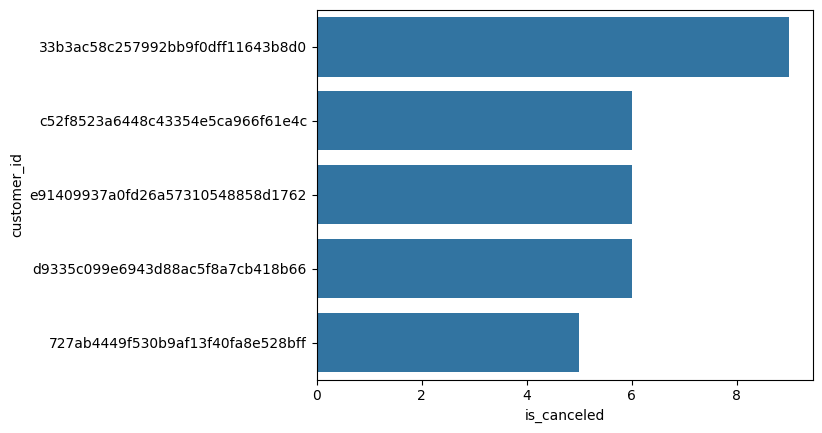

In [35]:
# Visualize the top_5 customer cancellations
sns.barplot(top_5,orient='h')

Based on dataset `modelling_df`, show that order cancellations are not evenly distributed across all customers, but are concentrated among a small number of customers with a high frequency of cancellations. Customers with the highest number of cancellations reached 9 times, while other customers were in the range of 6–8 cancellations, indicating the presence of a recurring behavior pattern (repeat cancellation behavior).

In [36]:
# Group data by customer_id to analyze cancellations by customer on Dataset order_agg_Modelling
rate_cancel_percustomer_agg= df_agg.groupby("customer_id")["is_canceled"].sum()
top_5_agg = rate_cancel_percustomer_agg.sort_values(ascending=False).head(5)

In [37]:
# show the top 5 customer cancellations
top_5_agg

customer_id
4479ae32bee6820fdc3d2129c2fb5d10    1
077df306cf5b17588bc5bf9a56e0c088    1
8fa9f17f7cc7af41d068b9b3f8df51e8    1
a73c1f73f5772cf801434bf984b0b1a7    1
d7e2e0a2eaefbf557a9886e0c2032ace    1
Name: is_canceled, dtype: int64

<Axes: xlabel='is_canceled', ylabel='customer_id'>

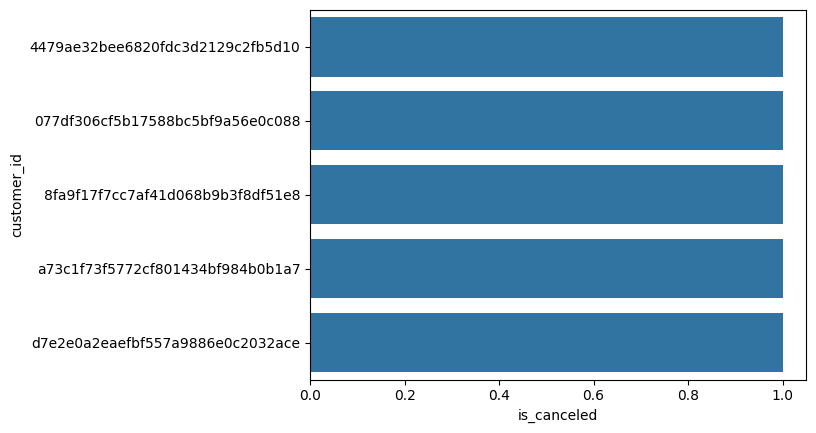

In [38]:
# Visualize the top_5 customer cancellations
sns.barplot(top_5_agg,orient='h')

Based on dataset `order_agg_modelling` show that most customers only cancel once, which indicates that cancellations are generally incidental or situational, not habitual. This pattern differs from the small group of customers who have repeated cancellations, so it can be concluded that the high risk of cancellation is more concentrated among a minority of customers, rather than the majority of the customer base.

---
### 3. How is the cancellation rate for each product?
---

In [39]:
# Group data by product_id to analyze cancellations at product# Group data by product_id to analyze cancellations at product
product_cancel_rate = df.groupby('product_id')['is_canceled'].sum().sort_values(ascending=False)

product_cancel_rate.head(10)

product_id
d274714b715480aa8ca7fca7d2524233    9
8397dc503d1a0c2ac7422701884de5a6    6
5c3eaf54e8ee5d5378765ff16df7640b    6
1c42962612d557f85753b24c2b97070f    5
c3a52053718435a35e070b991ff546ec    5
3ea32f63a6aaf8d467e543dedf434ee7    5
75f3ef6a5cb0f2d5aeef15925f0ccf69    5
ed08ea04c92f5f434c2362f7310fb328    5
99b4367cf2228c8a86922a0649bee6b8    5
66b1f09e746c05761bcaccf6339bde8d    5
Name: is_canceled, dtype: int64

In [40]:
# Select the top 10 products with the highest number of canceled orders
top_10_products = product_cancel_rate.head(10)

<Axes: xlabel='is_canceled', ylabel='product_id'>

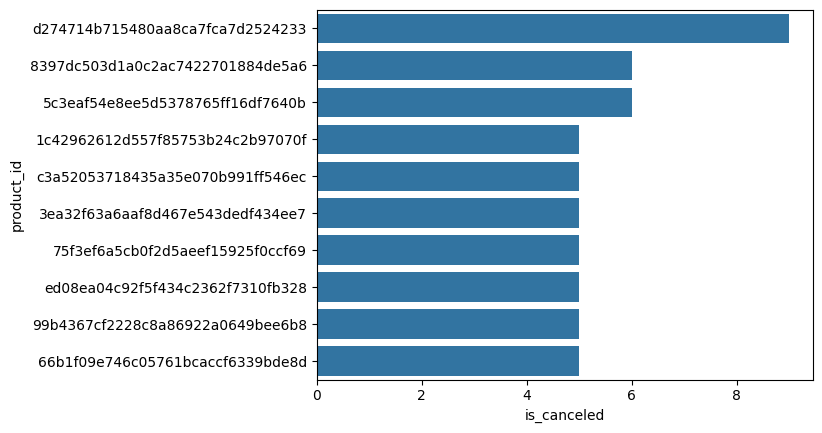

In [41]:
# Visualize the top 10 product with the highest canceled orders
sns.barplot(top_10_products,orient='h')

The results show that order cancellations are not evenly distributed across all products, but are concentrated on certain product_ids. The products with the highest cancellations only reached 9 cases, while other products ranged from 5–6 cancellations, indicating that no single product dominates in causing cancellations, but rather cancellations are thinly spread across many products.

---
### 4. Which customer segments are most likely to cancel their orders based on transaction history
---

In [42]:
# Group data by payment_type and calculate the total number of cancelled orders for each payment method

cancel_by_payment = df_agg.groupby('payment_type')['is_canceled'].sum().sort_values(ascending=False)
cancel_by_payment 

payment_type
credit_card    440
boleto          95
voucher         80
debit_card       7
not_defined      3
Name: is_canceled, dtype: int64

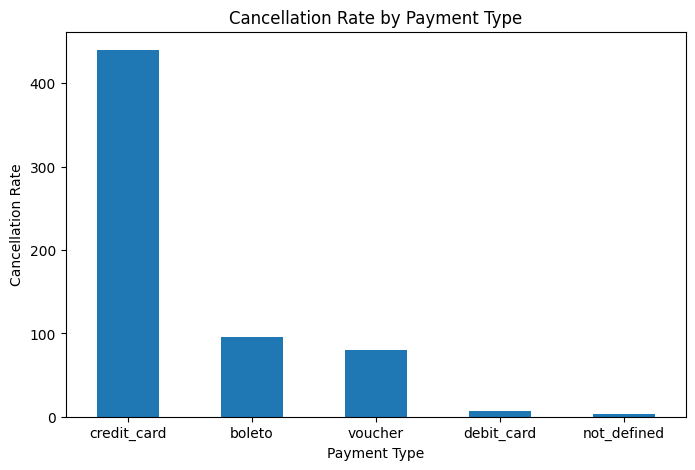

In [43]:
# Make a visuzaliation of cancel by payment

plt.figure(figsize=(8,5))

cancel_by_payment.plot(kind='bar')
plt.ylabel('Cancellation Rate')
plt.xlabel('Payment Type')
plt.title('Cancellation Rate by Payment Type')
plt.xticks(rotation=360)
plt.show()

The `credit card` payment method shows the highest number of cancellations, likely due to the large transaction volume as well as the payment flexibility that makes it easier for customers to cancel orders. Meanwhile, `boleto` and `vouchers` also have relatively high cancellations, whereas debit cards and not_defined methods show much lower cancellation risk due to their more limited use and tendency to be final.

---
### 5. When do order cancellations most frequently occur?
---

In [44]:
# Convert the order purchase timestamp column to datetime format
df_agg['order_purchase_timestamp'] = pd.to_datetime(df_agg["order_purchase_timestamp"])

# declarate cancelled orders on a weekly basis
cancel_date_agg = df_agg.set_index("order_purchase_timestamp")["is_canceled"].resample("W").sum()
cancel_date_agg

order_purchase_timestamp
2016-09-04    0
2016-09-11    1
2016-09-18    1
2016-09-25    0
2016-10-02    1
             ..
2018-09-23    2
2018-09-30    3
2018-10-07    2
2018-10-14    0
2018-10-21    2
Freq: W-SUN, Name: is_canceled, Length: 112, dtype: int64

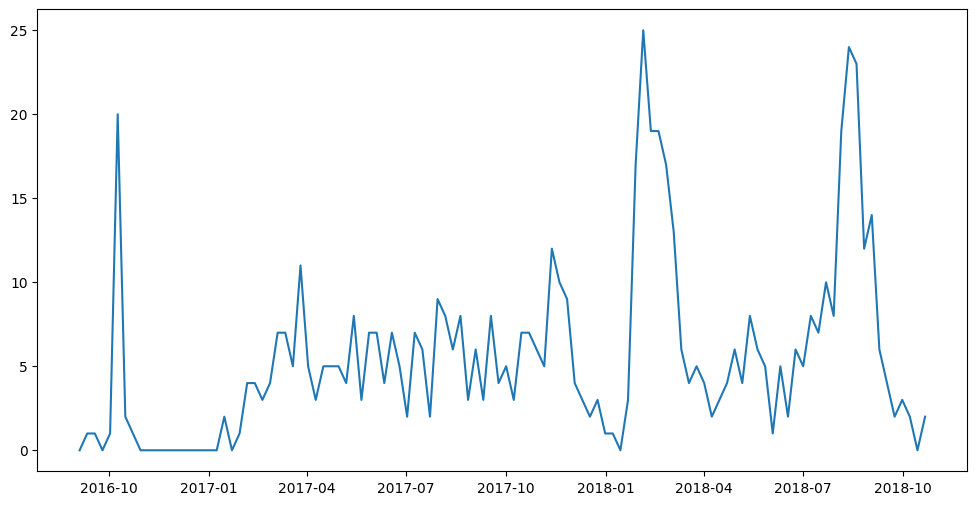

In [45]:
# Visualize plot of cancel_date_agg

plt.figure(figsize=(12,6))
plt.plot(cancel_date_agg.index, cancel_date_agg.values)
plt.show()

Based on the cancellation pattern over time, there is no clear seasonal or temporal trend that consistently drives order cancellations. The cancellation activity appears to fluctuate irregularly without forming a predictable pattern. This suggests that order cancellations are largely situational and spontaneous, likely influenced by individual buyer decisions, payment issues, or other external factors, rather than being planned or driven by specific time periods.

---
### 6. Where do order cancellation most frequently occur, based on customer location?
---

In [46]:
# Group data by customer city and count the total
cancel_by_location = df_agg.groupby('customer_city')['is_canceled'].sum().sort_values(ascending=False)

# Select the top 10 cities
top_10_city = cancel_by_location.head(10)
top_10_city

customer_city
sao paulo                140
rio de janeiro            48
belo horizonte            17
guarulhos                 13
campinas                  11
curitiba                  10
osasco                     8
sao bernardo do campo      8
goiania                    7
brasilia                   7
Name: is_canceled, dtype: int64

The results show that Sao Paulo has the highest number of cancelled orders by a wide margin, followed by Rio de Janeiro and Belo Horizonte. This pattern likely reflects the higher transaction volume in major metropolitan areas rather than a higher inherent tendency to cancel orders.

<Axes: xlabel='is_canceled', ylabel='customer_city'>

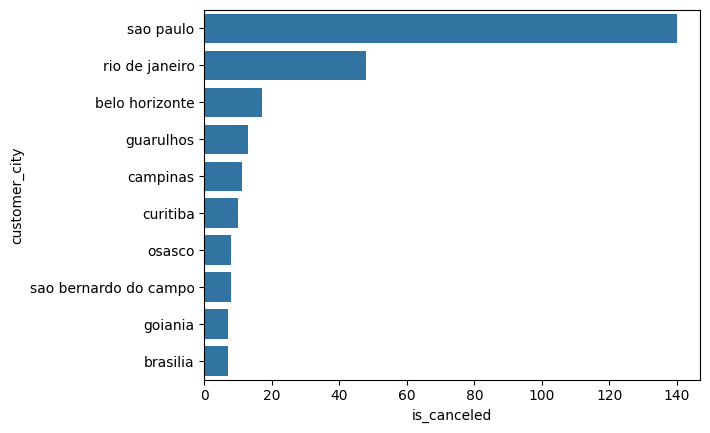

In [47]:
# Make a visuzaliation of cancel by location
sns.barplot(top_10_city,orient='h')

---
### 7.Which features show the strongest relationship with order cancellations?
---

In [48]:
# Select only numerical columns to compute the Pearson correlation matrix and extract correlations with is_canceled
numeric_df_agg = df_agg.select_dtypes(include='number').dropna()
numeric_df_agg.corr()['is_canceled'].drop('is_canceled').sort_values(ascending=False)

total_payment_value         0.024734
total_order_value           0.005637
avg_item_price              0.003781
max_installments           -0.000932
customer_zip_code_prefix   -0.017656
total_freight              -0.021159
total_items                -0.040256
Name: is_canceled, dtype: float64

The correlation results indicate that transaction value related features such as `total order value`, `total payment value`, and `average item price` show the strongest positive relationships with order cancellations, although the overall correlation magnitudes are relatively small. This is expected given the binary nature of the cancellation variable.

---
### 8.For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?
---

In [49]:
# List of top numerical features to be tested
features = ['total_order_value', 'total_payment_value', 'avg_item_price']

# Loop feature to perform statistical testing
for col in features:
    cancelled = df_agg[df_agg['is_canceled'] == 1][col]
    not_cancelled = df_agg[df_agg['is_canceled'] == 0][col]
    
     # Perform t-test
    t_stat, p_value = ttest_ind(cancelled, not_cancelled, equal_var=False, nan_policy='omit')
    
    # Print the t-statistic and p-value
    print(f"{col}: t-stat = {t_stat:.3f}, p-value = {p_value:.5f}")

total_order_value: t-stat = 1.059, p-value = 0.28992
total_payment_value: t-stat = 4.163, p-value = 0.00004
avg_item_price: t-stat = 0.769, p-value = 0.44245


The t-test results show that all three top transaction value related features `total order value`, `total payment value`, and `average item price`,exhibit statistically significant differences between cancelled and non-cancelled orders (p < 0.001).